In [78]:
import slangpy
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os 
cwd = Path(os.getcwd())

device = slangpy.create_device(slangpy.DeviceType.vulkan)
program = (cwd / "GGXPrecompute.slang").as_posix()    

integrateGGX_E = device.create_compute_kernel(device.load_program(program, ["integrateGGX_E"]))    
integrateGGX_Eavg = device.create_compute_kernel(device.load_program(program, ["integrateGGX_Eavg"]))
integrateGGX_IOR_E = device.create_compute_kernel(device.load_program(program, ["integrateGGX_IOR_E"]))
integrateGGX_IOR_Eavg = device.create_compute_kernel(device.load_program(program, ["integrateGGX_IOR_Eavg"]))


ggx_E = device.create_buffer(element_count=32*32, struct_size=8, format=slangpy.Format.rg32_float, usage=slangpy.BufferUsage.unordered_access)
ggx_Eavg = device.create_buffer(element_count=32, struct_size=4, format=slangpy.Format.r32_float, usage=slangpy.BufferUsage.unordered_access)
ggx_IOR_E = device.create_buffer(element_count=16*16*16, struct_size=4, format=slangpy.Format.r32_float, usage=slangpy.BufferUsage.unordered_access)
ggx_IOR_Eavg = device.create_buffer(element_count=32*32, struct_size=4, format=slangpy.Format.r32_float, usage=slangpy.BufferUsage.unordered_access)


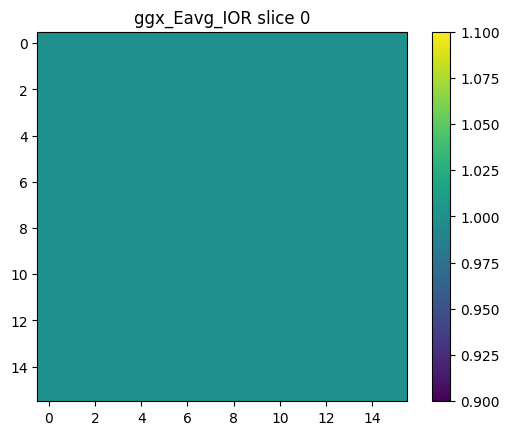

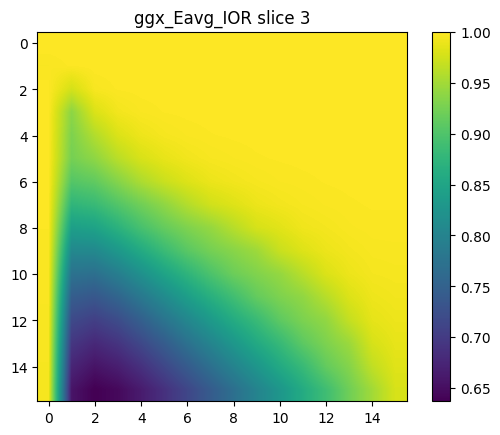

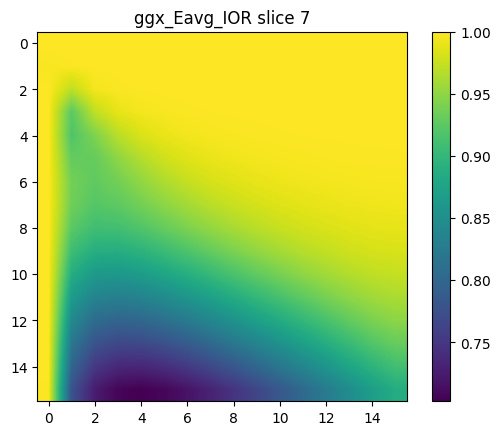

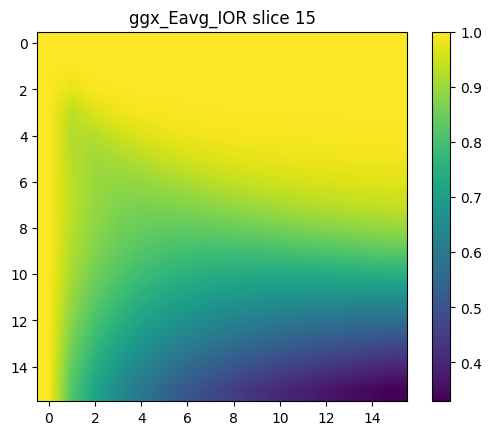

In [79]:
# Eavg IOR
integrateGGX_IOR_E.dispatch(thread_count=[1,1,16],vars={"ggxEIOR": ggx_IOR_E})
im_ggx_Eavg_IOR = ggx_IOR_E.to_numpy().reshape(16,16,16)
for slice in [0, 3, 7, 15]:
    plane = im_ggx_Eavg_IOR[slice,:,:]
    plt.imshow(plane, interpolation='bilinear')
    plt.title(f'ggx_Eavg_IOR slice {slice}')
    plt.colorbar()
    plt.show()


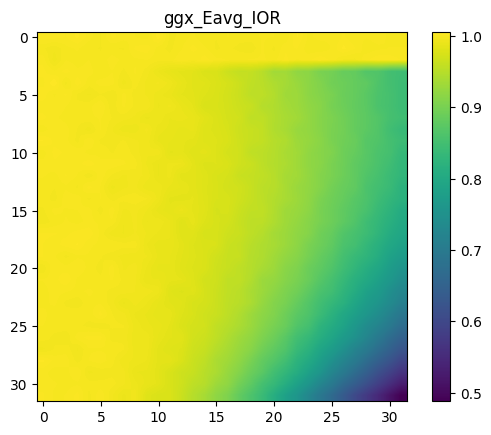

In [80]:
# Eavg
integrateGGX_IOR_Eavg.dispatch(thread_count=[1,1,1],vars={"ggxEIORavg": ggx_IOR_Eavg})
im_ggx_Eavg_IOR = ggx_IOR_Eavg.to_numpy().reshape(32,32)
plt.imshow(im_ggx_Eavg_IOR, interpolation='bilinear')
plt.title('ggx_Eavg_IOR')
plt.colorbar()
plt.show()

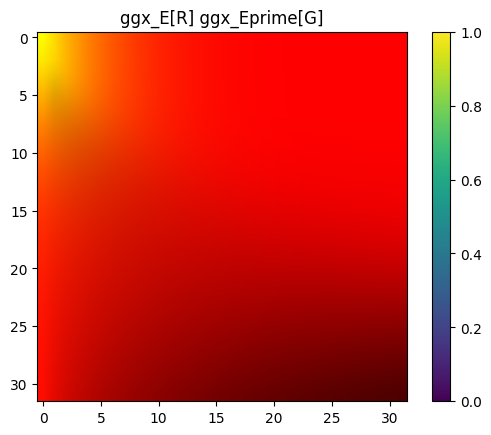

In [81]:
# E
integrateGGX_E.dispatch(thread_count=[1,1,1],vars={"ggxE": ggx_E})
im_ggx_E = ggx_E.to_numpy().reshape(32, 32, 2)
im_ggx_E = np.dstack([im_ggx_E, np.zeros((32, 32, 1), dtype=im_ggx_E.dtype)])
plt.imshow(im_ggx_E, interpolation='bilinear')
plt.title('ggx_E[R] ggx_Eprime[G]')
plt.colorbar()
plt.show()

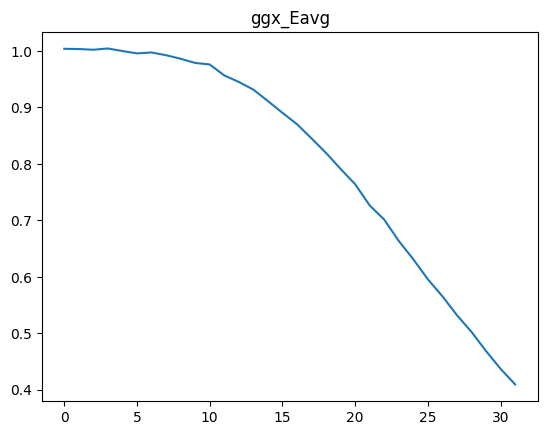

In [82]:
# Eavg
integrateGGX_Eavg.dispatch(thread_count=[1,1,1],vars={"ggxEavg": ggx_Eavg})
im_ggx_Eavg = ggx_Eavg.to_numpy()
plt.plot(im_ggx_Eavg)
plt.title('ggx_Eavg')
plt.show()

In [83]:
# Dump it.
# We don't use image containers for this as this would be uploaded back to GPU anyway
print("// Generated by Scripts/LUTPrecomputeGGX.ipynb")
print("constexpr float /* RG32 */ kGGXlutE[32 * 32 * 2] = {\n\t",end='')
for i, v in enumerate(ggx_E.to_numpy().flatten()):
    print(f"{v:.6f}f,", end=' ' if (i+1) % 32 else '\n\t')
print("\n};")

// Generated by Scripts/LUTPrecomputeGGX.ipynb
constexpr float /* RG32 */ kGGXlutE[32 * 32 * 2] = {
	1.000000f, 0.999988f, 1.000000f, 0.857431f, 1.000000f, 0.708990f, 1.000000f, 0.600387f, 1.000000f, 0.500093f, 1.000000f, 0.413274f, 1.000000f, 0.343176f, 1.000000f, 0.280422f, 1.000000f, 0.222802f, 1.000000f, 0.182083f, 1.000000f, 0.141899f, 1.000000f, 0.111034f, 1.000000f, 0.086071f, 1.000000f, 0.066125f, 1.000000f, 0.049831f, 1.000000f, 0.036702f,
	1.000000f, 0.026795f, 1.000000f, 0.018762f, 1.000000f, 0.012915f, 1.000000f, 0.008763f, 1.000000f, 0.005690f, 1.000000f, 0.003470f, 1.000000f, 0.002066f, 1.000000f, 0.001147f, 1.000000f, 0.000586f, 1.000000f, 0.000274f, 1.000000f, 0.000108f, 1.000000f, 0.000036f, 1.000000f, 0.000009f, 1.000000f, 0.000001f, 1.000000f, 0.000000f, 1.000000f, 0.000000f,
	0.982961f, 0.958506f, 0.999731f, 0.853476f, 0.999929f, 0.712852f, 0.999970f, 0.601628f, 0.999979f, 0.500282f, 0.999984f, 0.412284f, 0.999989f, 0.342694f, 0.999998f, 0.279783f, 0.999980f, 0.2232

In [84]:
print("constexpr float /* R32 */ kGGXlutEavg[32] = {\n\t",end='')
for v in ggx_Eavg.to_numpy():
    print(f"{v:.6f}f,", end=' ')
print("\n};")

constexpr float /* R32 */ kGGXlutEavg[32] = {
	1.003247f, 1.002809f, 1.001608f, 1.003832f, 0.999317f, 0.995132f, 0.996763f, 0.991883f, 0.985684f, 0.978230f, 0.975530f, 0.956134f, 0.944613f, 0.931024f, 0.910769f, 0.889938f, 0.869822f, 0.844616f, 0.818849f, 0.790604f, 0.763527f, 0.725918f, 0.700793f, 0.663081f, 0.630556f, 0.595162f, 0.565175f, 0.531612f, 0.502060f, 0.468067f, 0.436694f, 0.409082f, 
};


In [85]:
print("constexpr float /* R32 */ kGGXlutEIOR[16 * 16 * 16] = {\n\t",end='')
for i, v in enumerate(ggx_IOR_E.to_numpy().flatten()):
    print(f"{v:.6f}f,", end=' ' if (i+1) % 16 else '\n\t')
print("\n};")

constexpr float /* R32 */ kGGXlutEIOR[16 * 16 * 16] = {
	1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f,
	1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f,
	1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f,
	1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f,
	1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f,
	1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.000000f, 1.0

In [86]:
print("constexpr float /* R32 */ kGGXlutEIORavg[32 * 32] = {\n\t",end='')
for i, v in enumerate(ggx_IOR_Eavg.to_numpy().flatten()):
    print(f"{v:.6f}f,", end=' ' if (i+1) % 32 else '\n\t')
print("\n};")

constexpr float /* R32 */ kGGXlutEIORavg[32 * 32] = {
	1.003247f, 1.002813f, 1.001703f, 1.004296f, 1.000707f, 0.997684f, 1.002228f, 1.000725f, 0.999712f, 0.998624f, 1.005159f, 0.996895f, 0.998559f, 1.000104f, 0.997747f, 0.997835f, 0.999825f, 0.998655f, 0.999172f, 0.999923f, 0.999778f, 0.998001f, 1.004030f, 0.999223f, 1.000560f, 1.000092f, 1.001940f, 1.000374f, 0.999898f, 1.000862f, 0.999157f, 0.997865f,
	0.997960f, 0.996093f, 0.999031f, 1.000089f, 0.997993f, 0.997637f, 0.998014f, 0.997486f, 1.002169f, 1.003245f, 0.998632f, 0.997087f, 0.999499f, 1.002626f, 1.000172f, 0.997293f, 0.998331f, 0.997012f, 0.995873f, 1.000075f, 0.997181f, 1.001330f, 1.001826f, 0.998214f, 0.998083f, 0.999956f, 1.004400f, 1.001825f, 0.998302f, 0.999221f, 0.999841f, 0.999911f,
	1.001137f, 0.994536f, 0.999716f, 0.998568f, 0.999754f, 0.997921f, 1.001075f, 0.998797f, 0.999266f, 0.999759f, 0.998501f, 0.998580f, 1.001690f, 0.999672f, 1.002881f, 1.000329f, 0.999630f, 0.999547f, 0.999935f, 1.000168f, 0.998854f, 1.002393

In [87]:
# Dump to file
with open("../Source/Renderer/Tables/GGX_IOR.hpp", "w") as f:
    f.write("#pragma once\n")
    f.write("// Generated by Scripts/GGXPrecompute.ipynb\n")
    f.write("constexpr float kGGXlutEIOR[16 * 16 * 16] = {\n\t")
    for i, v in enumerate(ggx_IOR_E.to_numpy().flatten()):
        f.write(f"{v:.6f}f,{' ' if (i+1) % 16 else '\n\t'}")
    f.write("\n};\n")
    f.write("constexpr float kGGXlutEIORavg[32 * 32] = {\n\t")
    for i, v in enumerate(ggx_IOR_Eavg.to_numpy().flatten()):
        f.write(f"{v:.6f}f,{' ' if (i+1) % 32 else '\n\t'}")
    f.write("\n};\n")

In [88]:
with open("../Source/Renderer/Tables/GGX.hpp", "w") as f:
    f.write("#pragma once\n")
    f.write("// Generated by Scripts/GGXPrecompute.ipynb\n")
    f.write("constexpr float /* RG32 */ kGGXlutE[32 * 32 * 2] = {\n\t")
    for i, v in enumerate(ggx_E.to_numpy().flatten()):
        f.write(f"{v:.6f}f,{' ' if (i+1) % 32 else '\n\t'}")
    f.write("\n};\n")
    f.write("constexpr float /* R32 */ kGGXlutEavg[32] = {\n\t")
    for i, v in enumerate(ggx_Eavg.to_numpy().flatten()):
        f.write(f"{v:.6f}f,{' ' if (i+1) % 32 else '\n\t'}")
    f.write("\n};\n")